# ATP Match Prediction — Modeling

Leakage-free engineered features ile temporal cross-validation,
model comparison ve final holdout evaluation.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
)

In [2]:
project_root = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

processed_data_directory = (
    project_root / "data" / "processed"
)

model_data = pd.read_pickle(
    processed_data_directory
    / "atp_model_data_1990_2026.pkl"
)

feature_registry = json.loads(
    (
        processed_data_directory
        / "feature_registry.json"
    ).read_text(encoding="utf-8")
)


numeric_features = feature_registry[
    "numeric_features"
]

categorical_features = feature_registry[
    "categorical_features"
]

model_feature_columns = feature_registry[
    "model_feature_columns"
]

target_column = feature_registry["target"]


print("Dataset shape:", model_data.shape)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total features:", len(model_feature_columns))

Dataset shape: (95898, 127)
Numeric features: 113
Categorical features: 6
Total features: 119


In [3]:
missing_feature_columns = set(
    model_feature_columns
) - set(model_data.columns)

assert not missing_feature_columns

assert target_column not in model_feature_columns

assert model_data[
    "tourney_date"
].is_monotonic_increasing

assert model_data[target_column].isin([0, 1]).all()

print("Modeling dataset loaded correctly")

Modeling dataset loaded correctly


In [4]:
development_data = (
    model_data[
        model_data["source_year"] <= 2022
    ]
    .copy()
    .reset_index(drop=True)
)

test_data = (
    model_data[
        model_data["source_year"].between(
            2023,
            2025,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

live_2026_data = (
    model_data[
        model_data["source_year"].eq(2026)
    ]
    .copy()
    .reset_index(drop=True)
)


X_development = development_data[
    model_feature_columns
]

y_development = development_data[target_column]

X_test = test_data[model_feature_columns]
y_test = test_data[target_column]

X_live_2026 = live_2026_data[
    model_feature_columns
]

y_live_2026 = live_2026_data[target_column]


print("Development:", X_development.shape)
print("Final test:", X_test.shape)
print("2026 partial:", X_live_2026.shape)

Development: (86728, 119)
Final test: (7892, 119)
2026 partial: (1278, 119)


In [5]:
cv_periods = [
    (2002, 2003, 2006),
    (2006, 2007, 2010),
    (2010, 2011, 2014),
    (2014, 2015, 2018),
    (2018, 2019, 2022),
]


temporal_cv_splits = []


for fold_number, (
    train_end,
    validation_start,
    validation_end,
) in enumerate(cv_periods, start=1):

    train_indices = np.flatnonzero(
        development_data["source_year"]
        <= train_end
    )

    validation_indices = np.flatnonzero(
        development_data["source_year"].between(
            validation_start,
            validation_end,
        )
    )

    assert (
        development_data.loc[
            train_indices,
            "tourney_date",
        ].max()
        <
        development_data.loc[
            validation_indices,
            "tourney_date",
        ].min()
    )

    temporal_cv_splits.append(
        (
            train_indices,
            validation_indices,
        )
    )

    print(
        f"Fold {fold_number}: "
        f"train 1990–{train_end} "
        f"({len(train_indices):,}) | "
        f"validation "
        f"{validation_start}–{validation_end} "
        f"({len(validation_indices):,})"
    )

Fold 1: train 1990–2002 (36,179) | validation 2003–2006 (10,530)
Fold 2: train 1990–2006 (46,709) | validation 2007–2010 (10,557)
Fold 3: train 1990–2010 (57,266) | validation 2011–2014 (10,192)
Fold 4: train 1990–2014 (67,458) | validation 2015–2018 (10,248)
Fold 5: train 1990–2018 (77,706) | validation 2019–2022 (9,022)


In [6]:
from sklearn.base import clone


numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
            ),
        ),
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ],
    remainder="drop",
)


logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42,
            ),
        ),
    ]
)


print("Logistic Regression pipeline ready")

Logistic Regression pipeline ready


In [7]:
logistic_cv_results = []


for fold_number, (
    train_indices,
    validation_indices,
) in enumerate(
    temporal_cv_splits,
    start=1,
):
    fold_model = clone(logistic_pipeline)

    X_train_fold = X_development.iloc[
        train_indices
    ]

    y_train_fold = y_development.iloc[
        train_indices
    ]

    X_validation_fold = X_development.iloc[
        validation_indices
    ]

    y_validation_fold = y_development.iloc[
        validation_indices
    ]

    fold_model.fit(
        X_train_fold,
        y_train_fold,
    )

    validation_probability = (
        fold_model.predict_proba(
            X_validation_fold
        )[:, 1]
    )

    validation_prediction = (
        validation_probability >= 0.5
    ).astype(int)

    fold_result = {
        "fold": fold_number,
        "train_rows": len(train_indices),
        "validation_rows": len(
            validation_indices
        ),
        "accuracy": accuracy_score(
            y_validation_fold,
            validation_prediction,
        ),
        "roc_auc": roc_auc_score(
            y_validation_fold,
            validation_probability,
        ),
        "log_loss": log_loss(
            y_validation_fold,
            validation_probability,
        ),
        "brier_score": brier_score_loss(
            y_validation_fold,
            validation_probability,
        ),
    }

    logistic_cv_results.append(
        fold_result
    )

    print(
        f"Fold {fold_number} completed | "
        f"Accuracy: {fold_result['accuracy']:.4f} | "
        f"ROC-AUC: {fold_result['roc_auc']:.4f} | "
        f"Log loss: {fold_result['log_loss']:.4f}"
    )

Fold 1 completed | Accuracy: 0.6815 | ROC-AUC: 0.7524 | Log loss: 0.5871
Fold 2 completed | Accuracy: 0.6989 | ROC-AUC: 0.7710 | Log loss: 0.5704
Fold 3 completed | Accuracy: 0.7043 | ROC-AUC: 0.7762 | Log loss: 0.5646
Fold 4 completed | Accuracy: 0.6837 | ROC-AUC: 0.7532 | Log loss: 0.5872
Fold 5 completed | Accuracy: 0.6625 | ROC-AUC: 0.7313 | Log loss: 0.6024


In [8]:
logistic_cv_results = pd.DataFrame(
    logistic_cv_results
)

display(logistic_cv_results)


print("\nMean CV metrics")

display(
    logistic_cv_results[
        [
            "accuracy",
            "roc_auc",
            "log_loss",
            "brier_score",
        ]
    ]
    .agg(["mean", "std"])
    .round(4)
)

,fold,train_rows,validation_rows,accuracy,roc_auc,log_loss,brier_score
0,1,36179,10530,0.681481,0.752424,0.587094,0.201723
1,2,46709,10557,0.698873,0.771018,0.570373,0.194684
2,3,57266,10192,0.704278,0.776248,0.564627,0.192498
3,4,67458,10248,0.683743,0.753240,0.587209,0.201483
4,5,77706,9022,0.662492,0.731278,0.602385,0.208731



Mean CV metrics


,accuracy,roc_auc,log_loss,brier_score
mean,0.6862,0.7568,0.5823,0.1998
std,0.0164,0.0178,0.0150,0.0064


In [9]:
elo_cv_results = []


for fold_number, (
    _,
    validation_indices,
) in enumerate(
    temporal_cv_splits,
    start=1,
):
    validation_rows = development_data.iloc[
        validation_indices
    ]

    y_validation = validation_rows[
        target_column
    ]

    elo_probability = 1 / (
        1
        + 10 ** (
            -validation_rows["elo_difference"]
            / 400
        )
    )

    elo_prediction = (
        elo_probability >= 0.5
    ).astype(int)

    elo_cv_results.append(
        {
            "fold": fold_number,
            "accuracy": accuracy_score(
                y_validation,
                elo_prediction,
            ),
            "roc_auc": roc_auc_score(
                y_validation,
                elo_probability,
            ),
            "log_loss": log_loss(
                y_validation,
                elo_probability,
            ),
            "brier_score": brier_score_loss(
                y_validation,
                elo_probability,
            ),
        }
    )


elo_cv_results = pd.DataFrame(
    elo_cv_results
)

display(elo_cv_results)

display(
    elo_cv_results[
        [
            "accuracy",
            "roc_auc",
            "log_loss",
            "brier_score",
        ]
    ]
    .agg(["mean", "std"])
    .round(4)
)

,fold,accuracy,roc_auc,log_loss,brier_score
0,1,0.664577,0.727895,0.612555,0.211833
1,2,0.685327,0.751853,0.592150,0.203231
2,3,0.691915,0.759704,0.584647,0.200152
3,4,0.671741,0.739568,0.605924,0.208327
4,5,0.641100,0.705798,0.628326,0.219325


,accuracy,roc_auc,log_loss,brier_score
mean,0.6709,0.7370,0.6047,0.2086
std,0.0199,0.0212,0.0172,0.0075


In [10]:
surface_elo_cv_results = []


for fold_number, (
    _,
    validation_indices,
) in enumerate(
    temporal_cv_splits,
    start=1,
):
    validation_rows = development_data.iloc[
        validation_indices
    ]

    y_validation = validation_rows[
        target_column
    ]

    surface_elo_probability = 1 / (
        1
        + 10 ** (
            -validation_rows[
                "surface_elo_difference"
            ]
            / 400
        )
    )

    surface_elo_prediction = (
        surface_elo_probability >= 0.5
    ).astype(int)

    surface_elo_cv_results.append(
        {
            "fold": fold_number,
            "accuracy": accuracy_score(
                y_validation,
                surface_elo_prediction,
            ),
            "roc_auc": roc_auc_score(
                y_validation,
                surface_elo_probability,
            ),
            "log_loss": log_loss(
                y_validation,
                surface_elo_probability,
            ),
            "brier_score": brier_score_loss(
                y_validation,
                surface_elo_probability,
            ),
        }
    )


surface_elo_cv_results = pd.DataFrame(
    surface_elo_cv_results
)

display(surface_elo_cv_results)

display(
    surface_elo_cv_results[
        [
            "accuracy",
            "roc_auc",
            "log_loss",
            "brier_score",
        ]
    ]
    .agg(["mean", "std"])
    .round(4)
)

,fold,accuracy,roc_auc,log_loss,brier_score
0,1,0.662298,0.730326,0.609194,0.210624
1,2,0.679928,0.748576,0.592962,0.203823
2,3,0.687304,0.755422,0.586720,0.201284
3,4,0.669106,0.732269,0.610964,0.210721
4,5,0.640878,0.699841,0.633407,0.221419


,accuracy,roc_auc,log_loss,brier_score
mean,0.6679,0.7333,0.6066,0.2096
std,0.0179,0.0215,0.0182,0.0078


In [11]:
def evaluate_temporal_cv(
    model_pipeline,
    model_name,
):
    results = []

    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(
        temporal_cv_splits,
        start=1,
    ):
        fold_model = clone(model_pipeline)

        fold_model.fit(
            X_development.iloc[train_indices],
            y_development.iloc[train_indices],
        )

        probability = fold_model.predict_proba(
            X_development.iloc[
                validation_indices
            ]
        )[:, 1]

        prediction = (
            probability >= 0.5
        ).astype(int)

        y_validation = y_development.iloc[
            validation_indices
        ]

        result = {
            "model": model_name,
            "fold": fold_number,
            "accuracy": accuracy_score(
                y_validation,
                prediction,
            ),
            "roc_auc": roc_auc_score(
                y_validation,
                probability,
            ),
            "log_loss": log_loss(
                y_validation,
                probability,
            ),
            "brier_score": brier_score_loss(
                y_validation,
                probability,
            ),
        }

        results.append(result)

        print(
            f"{model_name} — Fold {fold_number} | "
            f"Accuracy: {result['accuracy']:.4f} | "
            f"ROC-AUC: {result['roc_auc']:.4f} | "
            f"Log loss: {result['log_loss']:.4f}"
        )

    return pd.DataFrame(results)

In [12]:
from sklearn.tree import DecisionTreeClassifier


decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=20,
                random_state=42,
            ),
        ),
    ]
)


print("Decision Tree pipeline ready")

Decision Tree pipeline ready


In [13]:
decision_tree_cv_results = evaluate_temporal_cv(
    decision_tree_pipeline,
    "Decision Tree",
)


display(
    decision_tree_cv_results[
        [
            "accuracy",
            "roc_auc",
            "log_loss",
            "brier_score",
        ]
    ]
    .agg(["mean", "std"])
    .round(4)
)

Decision Tree — Fold 1 | Accuracy: 0.6607 | ROC-AUC: 0.7233 | Log loss: 0.6683
Decision Tree — Fold 2 | Accuracy: 0.6849 | ROC-AUC: 0.7486 | Log loss: 0.6022
Decision Tree — Fold 3 | Accuracy: 0.6875 | ROC-AUC: 0.7511 | Log loss: 0.6207
Decision Tree — Fold 4 | Accuracy: 0.6778 | ROC-AUC: 0.7364 | Log loss: 0.6323
Decision Tree — Fold 5 | Accuracy: 0.6479 | ROC-AUC: 0.7079 | Log loss: 0.6477


,accuracy,roc_auc,log_loss,brier_score
mean,0.6718,0.7335,0.6342,0.2092
std,0.0170,0.0181,0.0253,0.0063


In [14]:
from sklearn.ensemble import RandomForestClassifier


random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=20,
                min_samples_leaf=5,
                max_features="sqrt",
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)


random_forest_cv_results = evaluate_temporal_cv(
    random_forest_pipeline,
    "Random Forest",
)


display(
    random_forest_cv_results[
        [
            "accuracy",
            "roc_auc",
            "log_loss",
            "brier_score",
        ]
    ]
    .agg(["mean", "std"])
    .round(4)
)

Random Forest — Fold 1 | Accuracy: 0.6790 | ROC-AUC: 0.7457 | Log loss: 0.5955
Random Forest — Fold 2 | Accuracy: 0.6945 | ROC-AUC: 0.7649 | Log loss: 0.5794
Random Forest — Fold 3 | Accuracy: 0.6988 | ROC-AUC: 0.7721 | Log loss: 0.5719
Random Forest — Fold 4 | Accuracy: 0.6812 | ROC-AUC: 0.7521 | Log loss: 0.5891
Random Forest — Fold 5 | Accuracy: 0.6537 | ROC-AUC: 0.7225 | Log loss: 0.6100


,accuracy,roc_auc,log_loss,brier_score
mean,0.6815,0.7514,0.5892,0.2023
std,0.0176,0.0192,0.0147,0.0065


In [15]:
from xgboost import XGBClassifier


xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=4,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)


print("XGBoost pipeline ready")

XGBoost pipeline ready


In [16]:
xgboost_cv_results = evaluate_temporal_cv(
    xgboost_pipeline,
    "XGBoost",
)


display(
    xgboost_cv_results[
        [
            "accuracy",
            "roc_auc",
            "log_loss",
            "brier_score",
        ]
    ]
    .agg(["mean", "std"])
    .round(4)
)

XGBoost — Fold 1 | Accuracy: 0.6818 | ROC-AUC: 0.7526 | Log loss: 0.5870
XGBoost — Fold 2 | Accuracy: 0.7005 | ROC-AUC: 0.7710 | Log loss: 0.5711
XGBoost — Fold 3 | Accuracy: 0.7032 | ROC-AUC: 0.7765 | Log loss: 0.5651
XGBoost — Fold 4 | Accuracy: 0.6849 | ROC-AUC: 0.7541 | Log loss: 0.5861
XGBoost — Fold 5 | Accuracy: 0.6586 | ROC-AUC: 0.7277 | Log loss: 0.6055


,accuracy,roc_auc,log_loss,brier_score
mean,0.6858,0.7564,0.5830,0.2000
std,0.0179,0.0191,0.0158,0.0069


In [17]:
metric_columns = [
    "accuracy",
    "roc_auc",
    "log_loss",
    "brier_score",
]


all_cv_results = {
    "Surface Elo": surface_elo_cv_results,
    "General Elo": elo_cv_results,
    "Decision Tree": decision_tree_cv_results,
    "Random Forest": random_forest_cv_results,
    "Logistic Regression": logistic_cv_results,
    "XGBoost": xgboost_cv_results,
}


model_leaderboard = pd.DataFrame(
    {
        model_name: results[
            metric_columns
        ].mean()
        for model_name, results
        in all_cv_results.items()
    }
).T.sort_values(
    "log_loss"
)


display(
    model_leaderboard.round(4)
)

,accuracy,roc_auc,log_loss,brier_score
Logistic Regression,0.6862,0.7568,0.5823,0.1998
XGBoost,0.6858,0.7564,0.5830,0.2000
Random Forest,0.6815,0.7514,0.5892,0.2023
General Elo,0.6709,0.7370,0.6047,0.2086
Surface Elo,0.6679,0.7333,0.6066,0.2096
Decision Tree,0.6718,0.7335,0.6342,0.2092


In [18]:
import time


latest_train_indices, latest_validation_indices = (
    temporal_cv_splits[-1]
)


diagnostic_models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgboost_pipeline,
}


diagnostic_results = []


for model_name, pipeline in diagnostic_models.items():
    model = clone(pipeline)

    start_time = time.perf_counter()

    model.fit(
        X_development.iloc[latest_train_indices],
        y_development.iloc[latest_train_indices],
    )

    fit_seconds = (
        time.perf_counter() - start_time
    )

    train_probability = model.predict_proba(
        X_development.iloc[latest_train_indices]
    )[:, 1]

    validation_probability = model.predict_proba(
        X_development.iloc[
            latest_validation_indices
        ]
    )[:, 1]

    diagnostic_results.append(
        {
            "model": model_name,
            "fit_seconds": fit_seconds,
            "train_accuracy": accuracy_score(
                y_development.iloc[
                    latest_train_indices
                ],
                train_probability >= 0.5,
            ),
            "validation_accuracy": accuracy_score(
                y_development.iloc[
                    latest_validation_indices
                ],
                validation_probability >= 0.5,
            ),
            "train_log_loss": log_loss(
                y_development.iloc[
                    latest_train_indices
                ],
                train_probability,
            ),
            "validation_log_loss": log_loss(
                y_development.iloc[
                    latest_validation_indices
                ],
                validation_probability,
            ),
        }
    )


diagnostic_results = pd.DataFrame(
    diagnostic_results
)

diagnostic_results["log_loss_gap"] = (
    diagnostic_results["validation_log_loss"]
    - diagnostic_results["train_log_loss"]
)


display(
    diagnostic_results.round(4)
)

,model,fit_seconds,train_accuracy,validation_accuracy,train_log_loss,validation_log_loss,log_loss_gap
0,Logistic Regression,6.9997,0.6833,0.6625,0.5885,0.6024,0.0139
1,Random Forest,27.9168,0.9064,0.6537,0.3833,0.6100,0.2267
2,XGBoost,20.0350,0.7084,0.6586,0.5572,0.6055,0.0483


In [19]:
random_forest_configs = {
    "RF_depth8_leaf50": {
        "max_depth": 8,
        "min_samples_leaf": 50,
    },
    "RF_depth12_leaf25": {
        "max_depth": 12,
        "min_samples_leaf": 25,
    },
    "RF_depth16_leaf10": {
        "max_depth": 16,
        "min_samples_leaf": 10,
    },
}


random_forest_tuning_results = []


for config_name, config in random_forest_configs.items():
    tuned_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=150,
                    max_depth=config["max_depth"],
                    min_samples_leaf=config[
                        "min_samples_leaf"
                    ],
                    max_features="sqrt",
                    max_samples=0.8,
                    n_jobs=-1,
                    random_state=42,
                ),
            ),
        ]
    )

    config_results = evaluate_temporal_cv(
        tuned_pipeline,
        config_name,
    )

    random_forest_tuning_results.append(
        config_results
    )


random_forest_tuning_results = pd.concat(
    random_forest_tuning_results,
    ignore_index=True,
)

RF_depth8_leaf50 — Fold 1 | Accuracy: 0.6791 | ROC-AUC: 0.7444 | Log loss: 0.5988
RF_depth8_leaf50 — Fold 2 | Accuracy: 0.6937 | ROC-AUC: 0.7636 | Log loss: 0.5830
RF_depth8_leaf50 — Fold 3 | Accuracy: 0.6953 | ROC-AUC: 0.7708 | Log loss: 0.5753
RF_depth8_leaf50 — Fold 4 | Accuracy: 0.6781 | ROC-AUC: 0.7490 | Log loss: 0.5919
RF_depth8_leaf50 — Fold 5 | Accuracy: 0.6463 | ROC-AUC: 0.7167 | Log loss: 0.6141
RF_depth12_leaf25 — Fold 1 | Accuracy: 0.6784 | ROC-AUC: 0.7473 | Log loss: 0.5947
RF_depth12_leaf25 — Fold 2 | Accuracy: 0.6961 | ROC-AUC: 0.7665 | Log loss: 0.5781
RF_depth12_leaf25 — Fold 3 | Accuracy: 0.6964 | ROC-AUC: 0.7726 | Log loss: 0.5712
RF_depth12_leaf25 — Fold 4 | Accuracy: 0.6794 | ROC-AUC: 0.7523 | Log loss: 0.5883
RF_depth12_leaf25 — Fold 5 | Accuracy: 0.6520 | ROC-AUC: 0.7204 | Log loss: 0.6107
RF_depth16_leaf10 — Fold 1 | Accuracy: 0.6812 | ROC-AUC: 0.7470 | Log loss: 0.5947
RF_depth16_leaf10 — Fold 2 | Accuracy: 0.6976 | ROC-AUC: 0.7661 | Log loss: 0.5782
RF_depth1

In [20]:
random_forest_tuning_summary = (
    random_forest_tuning_results
    .groupby("model")[
        [
            "accuracy",
            "roc_auc",
            "log_loss",
            "brier_score",
        ]
    ]
    .mean()
    .sort_values("log_loss")
)

display(
    random_forest_tuning_summary.round(4)
)

,accuracy,roc_auc,log_loss,brier_score
model,,,,
RF_depth16_leaf10,0.6832,0.7520,0.5884,0.2020
RF_depth12_leaf25,0.6805,0.7518,0.5886,0.2021
RF_depth8_leaf50,0.6785,0.7489,0.5926,0.2036


In [21]:
logistic_c_values = [
    0.01,
    0.1,
    1.0,
    10.0,
]


logistic_tuning_results = []


for c_value in logistic_c_values:
    tuned_logistic_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                LogisticRegression(
                    C=c_value,
                    max_iter=2000,
                    random_state=42,
                ),
            ),
        ]
    )

    config_results = evaluate_temporal_cv(
        tuned_logistic_pipeline,
        f"Logistic_C_{c_value}",
    )

    logistic_tuning_results.append(
        config_results
    )


logistic_tuning_results = pd.concat(
    logistic_tuning_results,
    ignore_index=True,
)

Logistic_C_0.01 — Fold 1 | Accuracy: 0.6822 | ROC-AUC: 0.7528 | Log loss: 0.5867
Logistic_C_0.01 — Fold 2 | Accuracy: 0.6976 | ROC-AUC: 0.7713 | Log loss: 0.5701
Logistic_C_0.01 — Fold 3 | Accuracy: 0.7045 | ROC-AUC: 0.7762 | Log loss: 0.5647
Logistic_C_0.01 — Fold 4 | Accuracy: 0.6832 | ROC-AUC: 0.7535 | Log loss: 0.5869
Logistic_C_0.01 — Fold 5 | Accuracy: 0.6642 | ROC-AUC: 0.7314 | Log loss: 0.6023
Logistic_C_0.1 — Fold 1 | Accuracy: 0.6821 | ROC-AUC: 0.7526 | Log loss: 0.5869
Logistic_C_0.1 — Fold 2 | Accuracy: 0.6988 | ROC-AUC: 0.7711 | Log loss: 0.5703
Logistic_C_0.1 — Fold 3 | Accuracy: 0.7046 | ROC-AUC: 0.7762 | Log loss: 0.5646
Logistic_C_0.1 — Fold 4 | Accuracy: 0.6836 | ROC-AUC: 0.7533 | Log loss: 0.5872
Logistic_C_0.1 — Fold 5 | Accuracy: 0.6647 | ROC-AUC: 0.7315 | Log loss: 0.6023
Logistic_C_1.0 — Fold 1 | Accuracy: 0.6815 | ROC-AUC: 0.7524 | Log loss: 0.5871
Logistic_C_1.0 — Fold 2 | Accuracy: 0.6989 | ROC-AUC: 0.7710 | Log loss: 0.5704
Logistic_C_1.0 — Fold 3 | Accuracy:

In [22]:
logistic_tuning_summary = (
    logistic_tuning_results
    .groupby("model")[
        [
            "accuracy",
            "roc_auc",
            "log_loss",
            "brier_score",
        ]
    ]
    .mean()
    .sort_values("log_loss")
)


display(
    logistic_tuning_summary.round(4)
)

,accuracy,roc_auc,log_loss,brier_score
model,,,,
Logistic_C_0.01,0.6863,0.7571,0.5821,0.1997
Logistic_C_0.1,0.6868,0.7569,0.5823,0.1998
Logistic_C_1.0,0.6862,0.7568,0.5823,0.1998
Logistic_C_10.0,0.6863,0.7568,0.5823,0.1998


In [23]:
xgboost_configs = {
    "XGB_shallow": {
        "n_estimators": 400,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_child_weight": 10,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 5.0,
        "reg_alpha": 0.1,
    },

    "XGB_balanced": {
        "n_estimators": 400,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_child_weight": 10,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 5.0,
        "reg_alpha": 0.1,
    },

    "XGB_strong_regularization": {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 20,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
        "reg_lambda": 10.0,
        "reg_alpha": 0.2,
    },
}

In [24]:
xgboost_tuning_results = []


for config_name, config in xgboost_configs.items():
    tuned_xgboost_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                XGBClassifier(
                    **config,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    tree_method="hist",
                    n_jobs=-1,
                    random_state=42,
                ),
            ),
        ]
    )

    config_results = evaluate_temporal_cv(
        tuned_xgboost_pipeline,
        config_name,
    )

    xgboost_tuning_results.append(
        config_results
    )


xgboost_tuning_results = pd.concat(
    xgboost_tuning_results,
    ignore_index=True,
)

XGB_shallow — Fold 1 | Accuracy: 0.6828 | ROC-AUC: 0.7538 | Log loss: 0.5864
XGB_shallow — Fold 2 | Accuracy: 0.7016 | ROC-AUC: 0.7731 | Log loss: 0.5696
XGB_shallow — Fold 3 | Accuracy: 0.7042 | ROC-AUC: 0.7770 | Log loss: 0.5653
XGB_shallow — Fold 4 | Accuracy: 0.6891 | ROC-AUC: 0.7557 | Log loss: 0.5847
XGB_shallow — Fold 5 | Accuracy: 0.6603 | ROC-AUC: 0.7278 | Log loss: 0.6053
XGB_balanced — Fold 1 | Accuracy: 0.6869 | ROC-AUC: 0.7542 | Log loss: 0.5858
XGB_balanced — Fold 2 | Accuracy: 0.7034 | ROC-AUC: 0.7733 | Log loss: 0.5691
XGB_balanced — Fold 3 | Accuracy: 0.7032 | ROC-AUC: 0.7777 | Log loss: 0.5643
XGB_balanced — Fold 4 | Accuracy: 0.6879 | ROC-AUC: 0.7555 | Log loss: 0.5845
XGB_balanced — Fold 5 | Accuracy: 0.6593 | ROC-AUC: 0.7287 | Log loss: 0.6044
XGB_strong_regularization — Fold 1 | Accuracy: 0.6824 | ROC-AUC: 0.7533 | Log loss: 0.5876
XGB_strong_regularization — Fold 2 | Accuracy: 0.7029 | ROC-AUC: 0.7721 | Log loss: 0.5711
XGB_strong_regularization — Fold 3 | Accura

In [25]:
xgboost_tuning_summary = (
    xgboost_tuning_results
    .groupby("model")[
        [
            "accuracy",
            "roc_auc",
            "log_loss",
            "brier_score",
        ]
    ]
    .mean()
    .sort_values("log_loss")
)


display(
    xgboost_tuning_summary.round(4)
)

,accuracy,roc_auc,log_loss,brier_score
model,,,,
XGB_balanced,0.6881,0.7579,0.5816,0.1995
XGB_shallow,0.6876,0.7575,0.5823,0.1997
XGB_strong_regularization,0.6869,0.7567,0.5834,0.2000


In [26]:
logistic_finalist_results = (
    logistic_tuning_results[
        logistic_tuning_results["model"]
        .eq("Logistic_C_0.01")
    ]
    .set_index("fold")
)


xgboost_finalist_results = (
    xgboost_tuning_results[
        xgboost_tuning_results["model"]
        .eq("XGB_balanced")
    ]
    .set_index("fold")
)


finalist_fold_comparison = pd.DataFrame(
    {
        "logistic_accuracy": (
            logistic_finalist_results["accuracy"]
        ),
        "xgboost_accuracy": (
            xgboost_finalist_results["accuracy"]
        ),
        "logistic_roc_auc": (
            logistic_finalist_results["roc_auc"]
        ),
        "xgboost_roc_auc": (
            xgboost_finalist_results["roc_auc"]
        ),
        "logistic_log_loss": (
            logistic_finalist_results["log_loss"]
        ),
        "xgboost_log_loss": (
            xgboost_finalist_results["log_loss"]
        ),
        "logistic_brier": (
            logistic_finalist_results["brier_score"]
        ),
        "xgboost_brier": (
            xgboost_finalist_results["brier_score"]
        ),
    }
)


display(
    finalist_fold_comparison.round(4)
)


print(
    "XGBoost log-loss fold wins:",
    (
        finalist_fold_comparison[
            "xgboost_log_loss"
        ]
        <
        finalist_fold_comparison[
            "logistic_log_loss"
        ]
    ).sum(),
    "/ 5",
)

,logistic_accuracy,xgboost_accuracy,logistic_roc_auc,xgboost_roc_auc,logistic_log_loss,xgboost_log_loss,logistic_brier,xgboost_brier
fold,,,,,,,,
1,0.6822,0.6869,0.7528,0.7542,0.5867,0.5858,0.2016,0.2011
2,0.6976,0.7034,0.7713,0.7733,0.5701,0.5691,0.1946,0.1939
3,0.7045,0.7032,0.7762,0.7777,0.5647,0.5643,0.1925,0.1920
4,0.6832,0.6879,0.7535,0.7555,0.5869,0.5845,0.2014,0.2006
5,0.6642,0.6593,0.7314,0.7287,0.6023,0.6044,0.2087,0.2097


XGBoost log-loss fold wins: 4 / 5


In [27]:
best_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                C=0.01,
                max_iter=2000,
                random_state=42,
            ),
        ),
    ]
)


best_xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                **xgboost_configs["XGB_balanced"],
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)

In [28]:
latest_train_indices, latest_validation_indices = (
    temporal_cv_splits[-1]
)

recent_year_results = []


for model_name, pipeline in {
    "Logistic Regression": best_logistic_pipeline,
    "XGBoost": best_xgboost_pipeline,
}.items():

    model = clone(pipeline)

    model.fit(
        X_development.iloc[latest_train_indices],
        y_development.iloc[latest_train_indices],
    )

    validation_probability = model.predict_proba(
        X_development.iloc[
            latest_validation_indices
        ]
    )[:, 1]

    recent_predictions = development_data.iloc[
        latest_validation_indices
    ][
        ["source_year", target_column]
    ].copy()

    recent_predictions["probability"] = (
        validation_probability
    )

    for year, year_rows in (
        recent_predictions.groupby("source_year")
    ):
        recent_year_results.append(
            {
                "model": model_name,
                "year": year,
                "matches": len(year_rows),
                "accuracy": accuracy_score(
                    year_rows[target_column],
                    year_rows["probability"] >= 0.5,
                ),
                "roc_auc": roc_auc_score(
                    year_rows[target_column],
                    year_rows["probability"],
                ),
                "log_loss": log_loss(
                    year_rows[target_column],
                    year_rows["probability"],
                ),
                "brier_score": brier_score_loss(
                    year_rows[target_column],
                    year_rows["probability"],
                ),
            }
        )


recent_year_results = pd.DataFrame(
    recent_year_results
)


display(
    recent_year_results.round(4)
)

,model,year,matches,accuracy,roc_auc,log_loss,brier_score
0,Logistic Regression,2019,2555,0.6591,0.7161,0.6156,0.2142
1,Logistic Regression,2020,1323,0.6636,0.7366,0.5943,0.2061
2,Logistic Regression,2021,2522,0.6642,0.7305,0.6029,0.2090
3,Logistic Regression,2022,2622,0.6693,0.7440,0.5928,0.2043
4,XGBoost,2019,2555,0.6626,0.7148,0.6162,0.2146
5,XGBoost,2020,1323,0.6538,0.7326,0.5989,0.2080
6,XGBoost,2021,2522,0.6534,0.7274,0.6048,0.2101
7,XGBoost,2022,2622,0.6644,0.7412,0.5952,0.2054


In [29]:
logistic_oof_predictions = []


for fold_number, (
    train_indices,
    validation_indices,
) in enumerate(
    temporal_cv_splits,
    start=1,
):
    fold_model = clone(
        best_logistic_pipeline
    )

    fold_model.fit(
        X_development.iloc[train_indices],
        y_development.iloc[train_indices],
    )

    probabilities = fold_model.predict_proba(
        X_development.iloc[
            validation_indices
        ]
    )[:, 1]

    fold_predictions = pd.DataFrame(
        {
            "fold": fold_number,
            "target": y_development.iloc[
                validation_indices
            ].to_numpy(),
            "probability": probabilities,
        }
    )

    logistic_oof_predictions.append(
        fold_predictions
    )


logistic_oof_predictions = pd.concat(
    logistic_oof_predictions,
    ignore_index=True,
)

In [30]:
logistic_oof_predictions[
    "probability_bin"
] = pd.qcut(
    logistic_oof_predictions["probability"],
    q=10,
    duplicates="drop",
)


calibration_table = (
    logistic_oof_predictions
    .groupby(
        "probability_bin",
        observed=True,
    )
    .agg(
        matches=("target", "size"),
        average_prediction=(
            "probability",
            "mean",
        ),
        actual_win_rate=(
            "target",
            "mean",
        ),
    )
)


calibration_table["absolute_gap"] = (
    calibration_table["average_prediction"]
    - calibration_table["actual_win_rate"]
).abs()


display(
    calibration_table.round(4)
)


expected_calibration_error = (
    calibration_table["absolute_gap"]
    * calibration_table["matches"]
    / calibration_table["matches"].sum()
).sum()


print(
    "Expected calibration error:",
    round(expected_calibration_error, 4),
)

,matches,average_prediction,actual_win_rate,absolute_gap
probability_bin,,,,
"(-0.0005560000000000001, 0.202]",5055,0.1282,0.1230,0.0052
"(0.202, 0.298]",5055,0.2523,0.2382,0.0141
"(0.298, 0.374]",5055,0.3373,0.3272,0.0101
"(0.374, 0.442]",5055,0.4090,0.4055,0.0034
"(0.442, 0.506]",5055,0.4743,0.4736,0.0007
"(0.506, 0.569]",5054,0.5375,0.5414,0.0038
"(0.569, 0.635]",5055,0.6013,0.5891,0.0121
"(0.635, 0.71]",5055,0.6712,0.6708,0.0004
"(0.71, 0.807]",5055,0.7554,0.7569,0.0015


Expected calibration error: 0.0052


In [31]:
xgboost_oof_predictions = []


for fold_number, (
    train_indices,
    validation_indices,
) in enumerate(
    temporal_cv_splits,
    start=1,
):
    fold_model = clone(
        best_xgboost_pipeline
    )

    fold_model.fit(
        X_development.iloc[train_indices],
        y_development.iloc[train_indices],
    )

    probabilities = fold_model.predict_proba(
        X_development.iloc[
            validation_indices
        ]
    )[:, 1]

    xgboost_oof_predictions.append(
        pd.DataFrame(
            {
                "fold": fold_number,
                "target": y_development.iloc[
                    validation_indices
                ].to_numpy(),
                "probability": probabilities,
            }
        )
    )


xgboost_oof_predictions = pd.concat(
    xgboost_oof_predictions,
    ignore_index=True,
)

In [32]:
def calculate_ece(
    targets,
    probabilities,
    number_of_bins=10,
):
    calibration_data = pd.DataFrame(
        {
            "target": targets,
            "probability": probabilities,
        }
    )

    calibration_data["bin"] = pd.qcut(
        calibration_data["probability"],
        q=number_of_bins,
        duplicates="drop",
    )

    grouped = calibration_data.groupby(
        "bin",
        observed=True,
    ).agg(
        matches=("target", "size"),
        predicted=("probability", "mean"),
        actual=("target", "mean"),
    )

    return (
        (
            grouped["predicted"]
            - grouped["actual"]
        ).abs()
        * grouped["matches"]
        / grouped["matches"].sum()
    ).sum()


finalist_oof_comparison = []


for model_name, predictions in {
    "Logistic Regression": (
        logistic_oof_predictions
    ),
    "XGBoost": xgboost_oof_predictions,
}.items():

    probability = predictions["probability"]
    target = predictions["target"]

    finalist_oof_comparison.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(
                target,
                probability >= 0.5,
            ),
            "roc_auc": roc_auc_score(
                target,
                probability,
            ),
            "log_loss": log_loss(
                target,
                probability,
            ),
            "brier_score": brier_score_loss(
                target,
                probability,
            ),
            "calibration_error": calculate_ece(
                target,
                probability,
            ),
        }
    )


finalist_oof_comparison = pd.DataFrame(
    finalist_oof_comparison
).set_index("model")


display(
    finalist_oof_comparison.round(5)
)

,accuracy,roc_auc,log_loss,brier_score,calibration_error
model,,,,,
Logistic Regression,0.68690,0.75807,0.58163,0.19951,0.00520
XGBoost,0.68892,0.75900,0.58106,0.19920,0.00921


In [33]:
from sklearn.neural_network import MLPClassifier


neural_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
            ),
        ),
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)


neural_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            neural_categorical_pipeline,
            categorical_features,
        ),
    ],
    remainder="drop",
    sparse_threshold=0,
)

In [34]:
neural_network_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            neural_preprocessor,
        ),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.001,
                batch_size=256,
                learning_rate_init=0.001,
                max_iter=150,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=10,
                random_state=42,
            ),
        ),
    ]
)


print("Neural Network pipeline ready")

Neural Network pipeline ready


In [35]:
neural_network_cv_results = evaluate_temporal_cv(
    neural_network_pipeline,
    "Neural Network",
)


display(
    neural_network_cv_results[
        [
            "accuracy",
            "roc_auc",
            "log_loss",
            "brier_score",
        ]
    ]
    .agg(["mean", "std"])
    .round(4)
)

Neural Network — Fold 1 | Accuracy: 0.6814 | ROC-AUC: 0.7484 | Log loss: 0.5906
Neural Network — Fold 2 | Accuracy: 0.6906 | ROC-AUC: 0.7612 | Log loss: 0.5813
Neural Network — Fold 3 | Accuracy: 0.6996 | ROC-AUC: 0.7699 | Log loss: 0.5713
Neural Network — Fold 4 | Accuracy: 0.6840 | ROC-AUC: 0.7514 | Log loss: 0.5895
Neural Network — Fold 5 | Accuracy: 0.6563 | ROC-AUC: 0.7228 | Log loss: 0.6125


,accuracy,roc_auc,log_loss,brier_score
mean,0.6824,0.7507,0.5890,0.2025
std,0.0162,0.0178,0.0152,0.0066


In [36]:
assert np.array_equal(
    logistic_oof_predictions["target"],
    xgboost_oof_predictions["target"],
)


ensemble_search_results = []

targets = logistic_oof_predictions[
    "target"
].to_numpy()

logistic_probabilities = (
    logistic_oof_predictions[
        "probability"
    ].to_numpy()
)

xgboost_probabilities = (
    xgboost_oof_predictions[
        "probability"
    ].to_numpy()
)


for xgboost_weight in np.arange(
    0.0,
    1.01,
    0.1,
):
    logistic_weight = (
        1.0 - xgboost_weight
    )

    ensemble_probability = (
        xgboost_weight
        * xgboost_probabilities
        + logistic_weight
        * logistic_probabilities
    )

    ensemble_search_results.append(
        {
            "xgboost_weight": xgboost_weight,
            "logistic_weight": logistic_weight,
            "accuracy": accuracy_score(
                targets,
                ensemble_probability >= 0.5,
            ),
            "roc_auc": roc_auc_score(
                targets,
                ensemble_probability,
            ),
            "log_loss": log_loss(
                targets,
                ensemble_probability,
            ),
            "brier_score": brier_score_loss(
                targets,
                ensemble_probability,
            ),
            "calibration_error": calculate_ece(
                targets,
                ensemble_probability,
            ),
        }
    )


ensemble_search_results = (
    pd.DataFrame(
        ensemble_search_results
    )
    .sort_values("log_loss")
)


display(
    ensemble_search_results.round(5)
)

,xgboost_weight,logistic_weight,accuracy,roc_auc,log_loss,brier_score,calibration_error
6,0.6,0.4,0.68785,0.75990,0.58012,0.19884,0.00946
5,0.5,0.5,0.68759,0.75987,0.58013,0.19885,0.00883
7,0.7,0.3,0.68866,0.75983,0.58021,0.19887,0.00844
4,0.4,0.6,0.68757,0.75972,0.58023,0.19890,0.00819
8,0.8,0.2,0.68901,0.75965,0.58040,0.19894,0.00925
3,0.3,0.7,0.68793,0.75947,0.58043,0.19899,0.00791
9,0.9,0.1,0.68917,0.75938,0.58068,0.19905,0.00890
2,0.2,0.8,0.68805,0.75911,0.58072,0.19913,0.00781
10,1.0,0.0,0.68892,0.75900,0.58106,0.19920,0.00921
1,0.1,0.9,0.68719,0.75864,0.58112,0.19930,0.00659


In [37]:
final_xgboost_model = clone(
    best_xgboost_pipeline
)

final_logistic_model = clone(
    best_logistic_pipeline
)


final_xgboost_model.fit(
    X_development,
    y_development,
)

final_logistic_model.fit(
    X_development,
    y_development,
)


xgboost_test_probability = (
    final_xgboost_model.predict_proba(
        X_test
    )[:, 1]
)

logistic_test_probability = (
    final_logistic_model.predict_proba(
        X_test
    )[:, 1]
)


test_probability = (
    0.60 * xgboost_test_probability
    + 0.40 * logistic_test_probability
)


test_prediction = (
    test_probability >= 0.5
).astype(int)


final_test_metrics = pd.Series(
    {
        "accuracy": accuracy_score(
            y_test,
            test_prediction,
        ),
        "roc_auc": roc_auc_score(
            y_test,
            test_probability,
        ),
        "log_loss": log_loss(
            y_test,
            test_probability,
        ),
        "brier_score": brier_score_loss(
            y_test,
            test_probability,
        ),
    },
    name="Ensemble — 2023–2025 Final Test",
)


display(
    final_test_metrics
    .to_frame()
    .round(5)
)

,Ensemble — 2023–2025 Final Test
accuracy,0.66194
roc_auc,0.72557
log_loss,0.60831
brier_score,0.21117


In [38]:
elo_test_probability = 1 / (
    1
    + 10 ** (
        -test_data["elo_difference"]
        / 400
    )
)


elo_test_prediction = (
    elo_test_probability >= 0.5
).astype(int)


test_benchmark_comparison = pd.DataFrame(
    {
        "General Elo": {
            "accuracy": accuracy_score(
                y_test,
                elo_test_prediction,
            ),
            "roc_auc": roc_auc_score(
                y_test,
                elo_test_probability,
            ),
            "log_loss": log_loss(
                y_test,
                elo_test_probability,
            ),
            "brier_score": brier_score_loss(
                y_test,
                elo_test_probability,
            ),
        },

        "Final Ensemble": {
            "accuracy": accuracy_score(
                y_test,
                test_prediction,
            ),
            "roc_auc": roc_auc_score(
                y_test,
                test_probability,
            ),
            "log_loss": log_loss(
                y_test,
                test_probability,
            ),
            "brier_score": brier_score_loss(
                y_test,
                test_probability,
            ),
        },
    }
).T


display(
    test_benchmark_comparison.round(5)
)

,accuracy,roc_auc,log_loss,brier_score
General Elo,0.64318,0.70513,0.63136,0.22029
Final Ensemble,0.66194,0.72557,0.60831,0.21117


In [39]:
test_result_analysis = test_data[
    [
        "source_year",
        "surface",
        "tourney_level",
        "target",
    ]
].copy()


test_result_analysis["probability"] = (
    test_probability
)


yearly_test_results = []


for year, year_rows in (
    test_result_analysis.groupby("source_year")
):
    yearly_test_results.append(
        {
            "year": year,
            "matches": len(year_rows),
            "accuracy": accuracy_score(
                year_rows["target"],
                year_rows["probability"] >= 0.5,
            ),
            "roc_auc": roc_auc_score(
                year_rows["target"],
                year_rows["probability"],
            ),
            "log_loss": log_loss(
                year_rows["target"],
                year_rows["probability"],
            ),
            "brier_score": brier_score_loss(
                year_rows["target"],
                year_rows["probability"],
            ),
        }
    )


display(
    pd.DataFrame(
        yearly_test_results
    ).round(4)
)

,year,matches,accuracy,roc_auc,log_loss,brier_score
0,2023,2674,0.6601,0.7229,0.6104,0.2121
1,2024,2655,0.6648,0.7306,0.6031,0.2091
2,2025,2563,0.6609,0.7230,0.6114,0.2123


In [40]:
def evaluate_training_start_year(
    training_start_year,
):
    results = []

    # Fold 1'i kullanmıyoruz:
    # 2000–2002 yalnızca üç yıllık training olurdu.
    for fold_number, (
        train_end,
        validation_start,
        validation_end,
    ) in enumerate(
        cv_periods[1:],
        start=2,
    ):
        train_indices = np.flatnonzero(
            development_data["source_year"].between(
                training_start_year,
                train_end,
            )
        )

        validation_indices = np.flatnonzero(
            development_data["source_year"].between(
                validation_start,
                validation_end,
            )
        )

        xgboost_model = clone(
            best_xgboost_pipeline
        )

        logistic_model = clone(
            best_logistic_pipeline
        )

        xgboost_model.fit(
            X_development.iloc[train_indices],
            y_development.iloc[train_indices],
        )

        logistic_model.fit(
            X_development.iloc[train_indices],
            y_development.iloc[train_indices],
        )

        xgboost_probability = (
            xgboost_model.predict_proba(
                X_development.iloc[
                    validation_indices
                ]
            )[:, 1]
        )

        logistic_probability = (
            logistic_model.predict_proba(
                X_development.iloc[
                    validation_indices
                ]
            )[:, 1]
        )

        ensemble_probability = (
            0.60 * xgboost_probability
            + 0.40 * logistic_probability
        )

        y_validation = y_development.iloc[
            validation_indices
        ]

        results.append(
            {
                "training_start_year": (
                    training_start_year
                ),
                "fold": fold_number,
                "train_rows": len(train_indices),
                "accuracy": accuracy_score(
                    y_validation,
                    ensemble_probability >= 0.5,
                ),
                "roc_auc": roc_auc_score(
                    y_validation,
                    ensemble_probability,
                ),
                "log_loss": log_loss(
                    y_validation,
                    ensemble_probability,
                ),
                "brier_score": brier_score_loss(
                    y_validation,
                    ensemble_probability,
                ),
            }
        )

        print(
            f"Start {training_start_year} — "
            f"Fold {fold_number} completed"
        )

    return pd.DataFrame(results)

In [41]:
start_1990_results = (
    evaluate_training_start_year(1990)
)

start_2000_results = (
    evaluate_training_start_year(2000)
)


training_start_comparison = (
    pd.concat(
        [
            start_1990_results,
            start_2000_results,
        ],
        ignore_index=True,
    )
    .groupby("training_start_year")[
        [
            "accuracy",
            "roc_auc",
            "log_loss",
            "brier_score",
        ]
    ]
    .mean()
)


display(
    training_start_comparison.round(5)
)

Start 1990 — Fold 2 completed
Start 1990 — Fold 3 completed
Start 1990 — Fold 4 completed
Start 1990 — Fold 5 completed
Start 2000 — Fold 2 completed
Start 2000 — Fold 3 completed
Start 2000 — Fold 4 completed
Start 2000 — Fold 5 completed


,accuracy,roc_auc,log_loss,brier_score
training_start_year,,,,
1990,0.6878,0.75974,0.57962,0.19867
2000,0.6886,0.75955,0.57973,0.19873


In [42]:
pre_2026_data = (
    model_data[
        model_data["source_year"] <= 2025
    ]
    .copy()
    .reset_index(drop=True)
)


X_pre_2026 = pre_2026_data[
    model_feature_columns
]

y_pre_2026 = pre_2026_data[
    target_column
]


production_xgboost_candidate = clone(
    best_xgboost_pipeline
)

production_logistic_candidate = clone(
    best_logistic_pipeline
)


production_xgboost_candidate.fit(
    X_pre_2026,
    y_pre_2026,
)

production_logistic_candidate.fit(
    X_pre_2026,
    y_pre_2026,
)


xgboost_2026_probability = (
    production_xgboost_candidate.predict_proba(
        X_live_2026
    )[:, 1]
)

logistic_2026_probability = (
    production_logistic_candidate.predict_proba(
        X_live_2026
    )[:, 1]
)


live_2026_probability = (
    0.60 * xgboost_2026_probability
    + 0.40 * logistic_2026_probability
)


live_2026_prediction = (
    live_2026_probability >= 0.5
).astype(int)


live_2026_metrics = pd.Series(
    {
        "accuracy": accuracy_score(
            y_live_2026,
            live_2026_prediction,
        ),
        "roc_auc": roc_auc_score(
            y_live_2026,
            live_2026_probability,
        ),
        "log_loss": log_loss(
            y_live_2026,
            live_2026_probability,
        ),
        "brier_score": brier_score_loss(
            y_live_2026,
            live_2026_probability,
        ),
    },
    name="2026 Partial Backtest",
)


display(
    live_2026_metrics
    .to_frame()
    .round(5)
)

,2026 Partial Backtest
accuracy,0.65962
roc_auc,0.73289
log_loss,0.60151
brier_score,0.20838


In [43]:
import joblib


X_all_available = model_data[
    model_feature_columns
]

y_all_available = model_data[
    target_column
]


production_xgboost_model = clone(
    best_xgboost_pipeline
)

production_logistic_model = clone(
    best_logistic_pipeline
)


production_xgboost_model.fit(
    X_all_available,
    y_all_available,
)

production_logistic_model.fit(
    X_all_available,
    y_all_available,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](119,)","['draw_size','best_of','round_order',...,'hand_matchup','p1_entry', 'p2_entry']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,119
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

In [44]:
models_directory = (
    project_root / "models"
)

models_directory.mkdir(
    parents=True,
    exist_ok=True,
)


joblib.dump(
    production_xgboost_model,
    models_directory
    / "xgboost_pipeline.joblib",
)

joblib.dump(
    production_logistic_model,
    models_directory
    / "logistic_pipeline.joblib",
)


ensemble_config = {
    "xgboost_weight": 0.60,
    "logistic_weight": 0.40,
    "decision_threshold": 0.50,
    "training_period": "1990–2026 partial",
    "primary_test_period": "2023–2025",
    "model_feature_count": len(
        model_feature_columns
    ),
}


(
    models_directory
    / "ensemble_config.json"
).write_text(
    json.dumps(
        ensemble_config,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print("Production models saved:", models_directory)

Production models saved: models/


In [45]:
xgboost_preprocessor = (
    production_xgboost_model
    .named_steps["preprocessor"]
)

xgboost_estimator = (
    production_xgboost_model
    .named_steps["model"]
)


transformed_feature_names = (
    xgboost_preprocessor
    .get_feature_names_out()
)


xgboost_feature_importance = (
    pd.DataFrame(
        {
            "feature": transformed_feature_names,
            "importance": (
                xgboost_estimator
                .feature_importances_
            ),
        }
    )
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    xgboost_feature_importance.head(30)
)

,feature,importance
0,numeric__elo_difference,0.221022
1,numeric__surface_elo_difference,0.132580
2,numeric__rank_points_difference,0.049076
3,numeric__rank_difference,0.025856
4,categorical__tourney_level_G,0.016697
5,numeric__tourney_game_win_rate_difference,0.015058
6,numeric__age_difference,0.013729
7,numeric__missingindicator_height_difference,0.009863
8,numeric__surface_experience_difference,0.009797
9,categorical__p1_entry_Q,0.009623


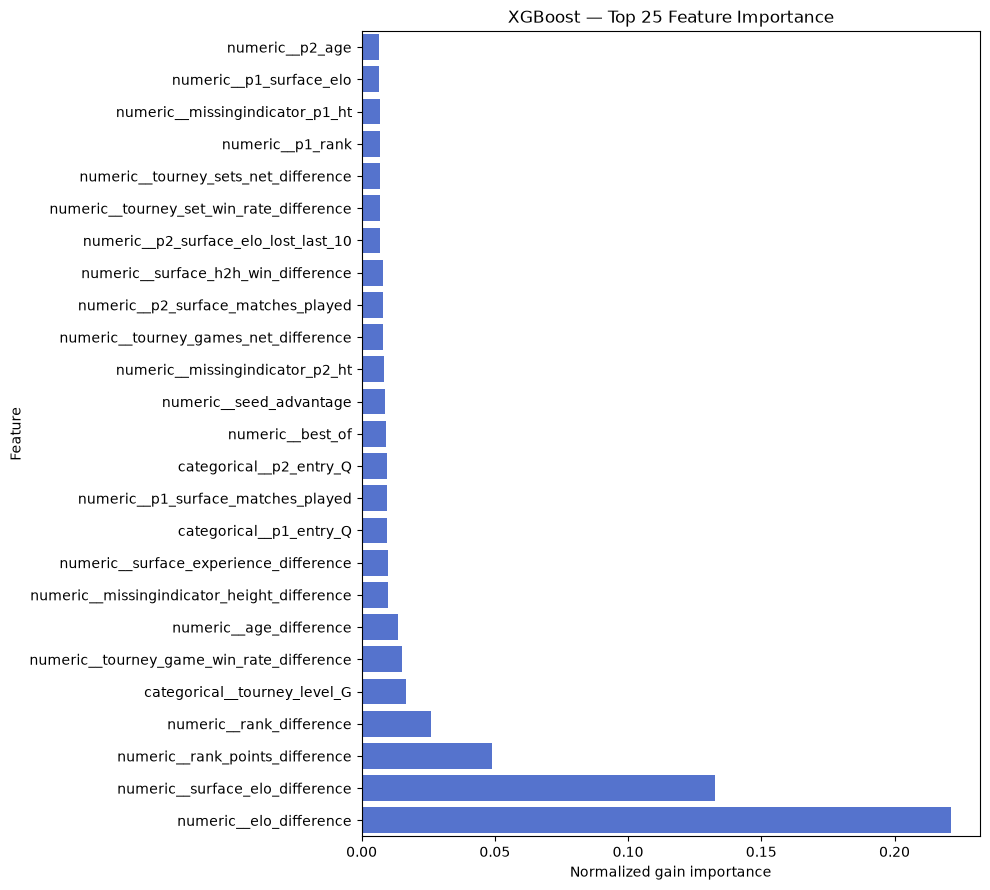

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns


top_feature_importance = (
    xgboost_feature_importance
    .head(25)
    .sort_values("importance")
)


plt.figure(figsize=(10, 9))

sns.barplot(
    data=top_feature_importance,
    x="importance",
    y="feature",
    color="royalblue",
)

plt.title(
    "XGBoost — Top 25 Feature Importance"
)

plt.xlabel("Normalized gain importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [47]:
final_error_analysis = test_data[
    [
        "surface",
        "tourney_level",
        "round",
        "target",
    ]
].copy()


final_error_analysis["probability"] = (
    test_probability
)

final_error_analysis["prediction"] = (
    test_prediction
)

final_error_analysis["correct"] = (
    final_error_analysis["prediction"]
    == final_error_analysis["target"]
)


def performance_by_group(
    data,
    group_column,
):
    results = []

    for group_value, rows in data.groupby(
        group_column
    ):
        results.append(
            {
                group_column: group_value,
                "matches": len(rows),
                "accuracy": accuracy_score(
                    rows["target"],
                    rows["prediction"],
                ),
                "roc_auc": roc_auc_score(
                    rows["target"],
                    rows["probability"],
                ),
                "log_loss": log_loss(
                    rows["target"],
                    rows["probability"],
                ),
                "brier_score": brier_score_loss(
                    rows["target"],
                    rows["probability"],
                ),
            }
        )

    return (
        pd.DataFrame(results)
        .sort_values("log_loss")
        .reset_index(drop=True)
    )


display(
    performance_by_group(
        final_error_analysis,
        "surface",
    ).round(4)
)

display(
    performance_by_group(
        final_error_analysis,
        "tourney_level",
    ).round(4)
)

display(
    performance_by_group(
        final_error_analysis,
        "round",
    ).round(4)
)

,surface,matches,accuracy,roc_auc,log_loss,brier_score
0,Hard,4575,0.6645,0.7301,0.6058,0.2100
1,Grass,921,0.6732,0.7218,0.6115,0.2126
2,Clay,2396,0.6528,0.7186,0.6118,0.2128


,tourney_level,matches,accuracy,roc_auc,log_loss,brier_score
0,G,1462,0.7339,0.8068,0.5326,0.1796
1,A,4280,0.6425,0.7052,0.6231,0.2175
2,M,2077,0.6509,0.7041,0.6295,0.2197
3,F,73,0.6712,0.6974,0.6575,0.2292


,round,matches,accuracy,roc_auc,log_loss,brier_score
0,R16,1430,0.6762,0.7369,0.6006,0.2075
1,R128,1268,0.6514,0.7204,0.6046,0.2112
2,R32,2509,0.6556,0.7270,0.6058,0.2101
3,R64,1247,0.6752,0.7274,0.6139,0.2125
4,QF,704,0.6662,0.7197,0.6179,0.2144
5,RR,165,0.6485,0.7173,0.6181,0.2150
6,F,194,0.6598,0.7088,0.6184,0.2158
7,SF,375,0.6400,0.7066,0.6209,0.2173


In [48]:
confidence_analysis = test_data[
    [
        "target",
    ]
].copy()


confidence_analysis["probability"] = (
    test_probability
)

confidence_analysis["prediction"] = (
    test_prediction
)

confidence_analysis["correct"] = (
    confidence_analysis["prediction"]
    == confidence_analysis["target"]
)

confidence_analysis[
    "predicted_winner_confidence"
] = np.maximum(
    confidence_analysis["probability"],
    1 - confidence_analysis["probability"],
)


confidence_bins = [
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
    0.75,
    0.80,
    0.90,
    1.00,
]


confidence_analysis["confidence_bin"] = pd.cut(
    confidence_analysis[
        "predicted_winner_confidence"
    ],
    bins=confidence_bins,
    include_lowest=True,
)


confidence_performance = (
    confidence_analysis
    .groupby(
        "confidence_bin",
        observed=True,
    )
    .agg(
        matches=("target", "size"),
        average_confidence=(
            "predicted_winner_confidence",
            "mean",
        ),
        accuracy=("correct", "mean"),
    )
)


confidence_performance["data_share"] = (
    confidence_performance["matches"]
    / len(confidence_analysis)
)


display(
    confidence_performance.round(4)
)

,matches,average_confidence,accuracy,data_share
confidence_bin,,,,
"(0.499, 0.55]",1319,0.5248,0.5398,0.1671
"(0.55, 0.6]",1221,0.5749,0.5430,0.1547
"(0.6, 0.65]",1173,0.6244,0.6130,0.1486
"(0.65, 0.7]",1046,0.6740,0.6558,0.1325
"(0.7, 0.75]",916,0.7243,0.7052,0.1161
"(0.75, 0.8]",797,0.7735,0.7503,0.1010
"(0.8, 0.9]",1045,0.8451,0.8096,0.1324
"(0.9, 1.0]",375,0.9316,0.9440,0.0475


In [49]:
confidence_threshold_results = []


for threshold in [
    0.55,
    0.60,
    0.65,
    0.70,
    0.75,
    0.80,
    0.90,
]:
    selected_matches = confidence_analysis[
        confidence_analysis[
            "predicted_winner_confidence"
        ] >= threshold
    ]

    confidence_threshold_results.append(
        {
            "minimum_confidence": threshold,
            "matches": len(selected_matches),
            "coverage": (
                len(selected_matches)
                / len(confidence_analysis)
            ),
            "accuracy": selected_matches[
                "correct"
            ].mean(),
        }
    )


confidence_threshold_results = pd.DataFrame(
    confidence_threshold_results
)


display(
    confidence_threshold_results.round(4)
)

,minimum_confidence,matches,coverage,accuracy
0,0.55,6573,0.8329,0.6864
1,0.60,5352,0.6782,0.7192
2,0.65,4179,0.5295,0.7490
3,0.70,3133,0.3970,0.7801
4,0.75,2217,0.2809,0.8110
5,0.80,1420,0.1799,0.8451
6,0.90,375,0.0475,0.9440


In [50]:
reports_directory = (
    project_root / "reports"
)

reports_directory.mkdir(
    parents=True,
    exist_ok=True,
)


evaluation_report = {
    "selected_algorithm": (
        "0.60 XGBoost + 0.40 Logistic Regression"
    ),
    "primary_metric": "log_loss",

    "final_test_2023_2025": {
        metric: float(value)
        for metric, value
        in final_test_metrics.items()
    },

    "backtest_2026_partial": {
        metric: float(value)
        for metric, value
        in live_2026_metrics.items()
    },

    "confidence_thresholds": [
        {
            "minimum_confidence": float(
                row.minimum_confidence
            ),
            "matches": int(row.matches),
            "coverage": float(row.coverage),
            "accuracy": float(row.accuracy),
        }
        for row in (
            confidence_threshold_results
            .itertuples(index=False)
        )
    ],
}


(
    reports_directory
    / "evaluation_report.json"
).write_text(
    json.dumps(
        evaluation_report,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

1491

In [51]:
test_prediction_export = test_data[
    [
        "source_year",
        "tourney_date",
        "tourney_name",
        "surface",
        "round",
        "p1_name",
        "p2_name",
        "target",
    ]
].copy()


test_prediction_export[
    "p1_win_probability"
] = test_probability

test_prediction_export[
    "predicted_winner"
] = np.where(
    test_probability >= 0.5,
    test_prediction_export["p1_name"],
    test_prediction_export["p2_name"],
)

test_prediction_export[
    "actual_winner"
] = np.where(
    test_prediction_export["target"].eq(1),
    test_prediction_export["p1_name"],
    test_prediction_export["p2_name"],
)

test_prediction_export["confidence"] = np.maximum(
    test_probability,
    1 - test_probability,
)

test_prediction_export["correct"] = (
    test_prediction_export["predicted_winner"]
    == test_prediction_export["actual_winner"]
)


test_prediction_export.to_csv(
    reports_directory
    / "test_predictions_2023_2025.csv",
    index=False,
)


print("Modeling reports saved:", reports_directory)

Modeling reports saved: reports/
